# 3_anomaly_model – Anomalieerkennung im Stromverbrauch

In diesem Notebook entwickle ich einen ersten Ansatz zur **automatischen Erkennung von Anomalien** im Stromverbrauch von Haushalten.
Ziel ist es, ungewöhnliche Verbrauchsmuster (z. B. Peaks, Ausfälle, atypische Tagesverläufe) zu markieren, um später:

- technische Auffälligkeiten frühzeitig zu erkennen
- Verbrauchsmuster besser zu verstehen
- die Ergebnisse in **Streamlit** und **Power BI** zu visualisieren

**Input:** `household_power_eda_ready.csv` (bereinigt + numerisch, Ergebnis aus Phase 2)  
**Output:** Datensatz mit Anomalie-Labels + Scores für Dashboards

## 1. Imports + Daten laden (aufgeräumter Code)


In [151]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt


In [152]:
# Pfad zum EDA-ready Datensatz (Output aus Notebook 2)
pfad_ready="C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Data\\bearbeitet\\household_power_eda_ready.csv"

In [153]:
df = pd.read_csv(
    pfad_ready,
    parse_dates=["Datetime"],
    index_col="Datetime"
)


## 2. Datencheck (kurz)

Bevor das Modell trainiert wird, prüfe ich:
- ob der Zeitindex korrekt ist (DatetimeIndex)
- ob fehlende Werte vorliegen
- ob numerische Spalten korrekt geladen wurden


In [154]:
print("Index-Typ:", type(df.index))
print("Fehlende Werte (Summe):")
display(df.isna().sum().sort_values(ascending=False).head(10))

df.dtypes


Index-Typ: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Fehlende Werte (Summe):


Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
hour                     0
weekday                  0
top1_peak                0
dtype: int64

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
hour                       int64
weekday                    int64
top1_peak                   bool
dtype: object

## 3. Datenvalidierung vor dem Training (Phase 3)

Bevor das Anomalie-Modell trainiert wird, prüfe ich kurz:
- keine negativen oder nicht-plausiblen Werte
- gleichmäßig sortierter Zeitindex
- keine langen Nullphasen (Hinweis auf Sensor-/Messfehler)

Diese Checks sind **modellnah** (Phase 3) und dienen dazu, technische Artefakte von echten Anomalien zu trennen.


In [155]:
# 1) Basischecks
print("Fehlende Werte gesamt:", int(df.isna().sum().sum()))
print("Negative Werte (Global_active_power):", int((df["Global_active_power"] < 0).sum()))
print("Index monoton steigend:", df.index.is_monotonic_increasing)

Fehlende Werte gesamt: 0
Negative Werte (Global_active_power): 0
Index monoton steigend: True


### Nullphasen-Check (Diagnose)

Zusätzlich wird geprüft, ob längere Phasen mit exakt 0 Verbrauch vorliegen.
Solche Muster können auf Messfehler oder Abwesenheit hindeuten und würden
die Anomalieerkennung verfälschen.

Dieser Check dient ausschließlich der Diagnose und wird **nicht**
als Feature im Modell verwendet.


In [156]:
# 2) Nullphasen-Check (Diagnose, nicht fürs Modell)
df_tmp = df.copy()
df_tmp["is_zero"] = (df_tmp["Global_active_power"] == 0).astype(int)
df_tmp["zero_streak"] = df_tmp["is_zero"].groupby(
    (df_tmp["is_zero"] != df_tmp["is_zero"].shift()).cumsum()
).cumsum()

max_zero_streak = df_tmp.loc[df_tmp["is_zero"] == 1, "zero_streak"].max()

if pd.isna(max_zero_streak):
    max_zero_streak = 0

print("Max. Zero-Streak:", int(max_zero_streak))


Max. Zero-Streak: 0


Leakage / Diagnose-Spalten entfernen

In [157]:
df = df.drop(columns=["is_zero", "zero_streak", "top1_peak"], errors="ignore")



In [158]:
df.head(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,weekday
Datetime,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,5
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,5
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,5


## 4.Zeitliche Aggregation (Resampling)

Für die Anomalieerkennung aggregiere ich die Messwerte auf **Stundenebene**.
Das reduziert Rauschen und macht Muster (Tages-/Wochenprofile) stabiler für das Modell.


In [159]:
# Resampling: 1 Stunde (nutze 'h' statt 'H')
df_h = df.resample("h").mean()

df_h.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,weekday
Datetime,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17.0,5.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18.0,5.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19.0,5.0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20.0,5.0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21.0,5.0


## 5. Feature Engineering

Für Isolation Forest nutze ich neben dem aktuellen Verbrauch auch Kontext-Features:
- Zeitmerkmale: Stunde, Wochentag, Wochenende
- Rolling-Statistiken (24h) für kurzfristige Normalwerte
- Lag-Features (1h, 24h) zur Abbildung kurzfristiger / täglicher Wiederholungen

Diese Features helfen dem Modell, "ungewöhnlich" relativ zum erwarteten Kontext zu bewerten.


In [160]:
# Zeitfeatures
df_h["hour"] = df_h.index.hour
df_h["weekday"] = df_h.index.weekday
df_h["is_weekend"] = (df_h["weekday"] >= 5).astype(int)

# Rolling Features (24h)
df_h["roll_mean_24"] = df_h["Global_active_power"].rolling(24).mean()
df_h["roll_std_24"]  = df_h["Global_active_power"].rolling(24).std()

# Lag Features
df_h["lag_1"]  = df_h["Global_active_power"].shift(1)
df_h["lag_24"] = df_h["Global_active_power"].shift(24)

# dtypes sauber halten
df_h["weekday"] = df_h["weekday"].astype(int)
df_h["hour"] = df_h["hour"].astype(int)


## 6. Trainingsmatrix erstellen

Durch Rolling- und Lag-Features entstehen am Anfang der Zeitreihe fehlende Werte.
Diese werden **nur für das Modelltraining** entfernt.


In [161]:
features = [
    "Global_active_power",
    "hour", "weekday", "is_weekend",
    "roll_mean_24", "roll_std_24",
    "lag_1", "lag_24"
]

X = df_h[features].dropna().copy()
print("Trainingsdaten:", X.shape)


Trainingsdaten: (33952, 8)


## 7. Isolation Forest: Training und Scoring

Isolation Forest ist ein unsupervised Modell, das Punkte als Anomalie markiert,
wenn sie im Feature-Raum schwer durch zufällige Splits "isolierbar" sind.

- `anomaly_if`: 1 = Anomalie, 0 = normal
- `if_score`: je höher, desto normaler (um 0 liegt ungefähr der Schwellenwert)


In [163]:
# X enthält NUR die Feature-Spalten (ohne anomaly/späteren Output)
X_features = X.copy()

iso = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42
)

iso.fit(X_features)

pred = iso.predict(X_features)
score = iso.decision_function(X_features)

# Ergebnisse separat speichern
X_out = X_features.copy()
X_out["anomaly_if"] = (pred == -1).astype(int)
X_out["if_score"] = score

X_out.head()




,Global_active_power,hour,weekday,is_weekend,roll_mean_24,roll_std_24,lag_1,lag_24,anomaly_if,if_score
Datetime,,,,,,,,,,
2006-12-17 17:00:00,3.406767,17,6,1,2.465140,0.752521,3.326033,4.222889,1,-0.051232
2006-12-17 18:00:00,3.697100,18,6,1,2.467844,0.757001,3.406767,3.632200,1,-0.047406
2006-12-17 19:00:00,2.908400,19,6,1,2.447351,0.737057,3.697100,3.400233,1,-0.043125
2006-12-17 20:00:00,3.361500,20,6,1,2.451224,0.741788,2.908400,3.268567,1,-0.042358
2006-12-17 21:00:00,3.040767,21,6,1,2.450569,0.741237,3.361500,3.056467,1,-0.045886


Ergebnis zurück in df_h mergen:

In [165]:
df_h = df_h.join(X_out[["anomaly_if", "if_score"]], how="left")
df_h["anomaly_if"] = df_h["anomaly_if"].fillna(0).astype(int)



## 8. Ergebnisse: Wie viele Anomalien wurden gefunden?

Die Parameterwahl `contamination=0.01` bedeutet, dass das Modell ca. 1% der Punkte
als potenzielle Anomalien markiert. Das dient als Startwert und kann später
je nach Use-Case angepasst werden.


In [ ]:
n = df_h["anomaly_if"].sum()
p = df_h["anomaly_if"].mean()
print(f"Anomalien: {n}  | Anteil: {p:.3%}")


Anomalien: 340  | Anteil: 0.983%


## 9. Visualisierung: Anomalien im Gesamtverlauf (stündlich)

Im Plot werden die stündlichen Verbrauchswerte dargestellt.
Die markierten Punkte zeigen die vom Isolation Forest erkannten Anomalien.


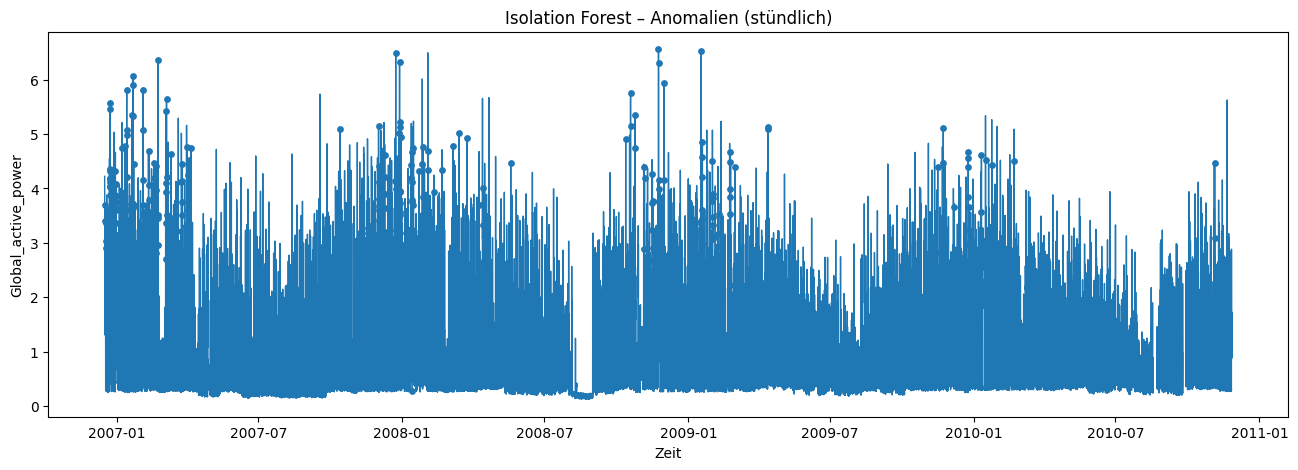

In [171]:
plt.figure(figsize=(16, 5))
plt.plot(df_h.index, df_h["Global_active_power"], linewidth=1)

anom = df_h[df_h["anomaly_if"] == 1]
plt.scatter(anom.index, anom["Global_active_power"], s=15)

plt.title("Isolation Forest – Anomalien (stündlich)")
plt.xlabel("Zeit")
plt.ylabel("Global_active_power")
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\anomalies\\Is_for_Anomalien.png", dpi=300)
plt.show()



## Detailansicht (Zoom)

Für eine bessere Interpretierbarkeit wird ein kurzer Zeitraum gezoomt.
So lassen sich einzelne Peaks und Muster leichter erkennen.


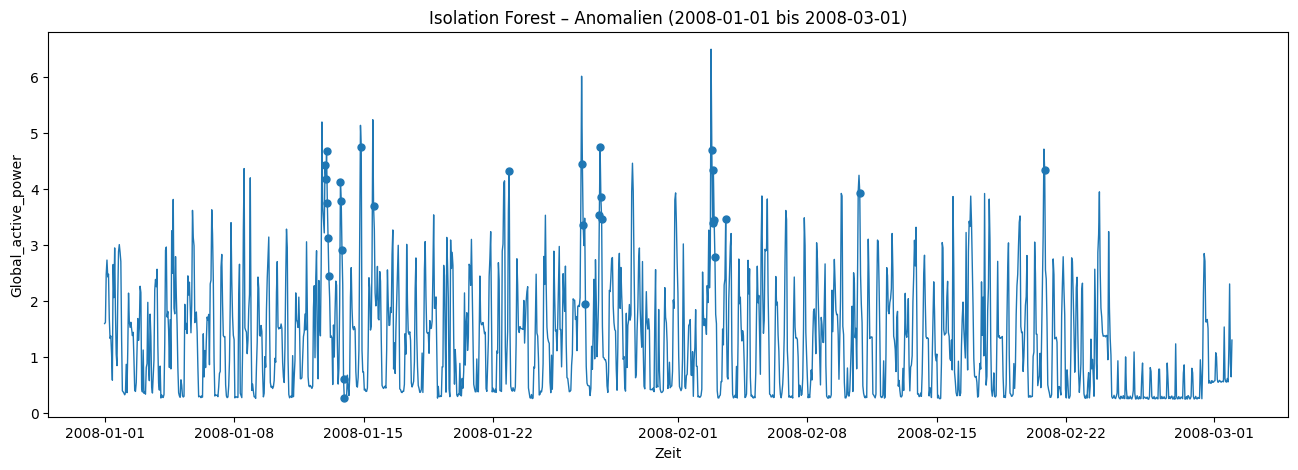

In [172]:
start, end = "2008-01-01", "2008-03-01"
tmp = df_h.loc[start:end]

plt.figure(figsize=(16, 5))
plt.plot(tmp.index, tmp["Global_active_power"], linewidth=1)

anom = tmp[tmp["anomaly_if"] == 1]
plt.scatter(anom.index, anom["Global_active_power"], s=25)

plt.title(f"Isolation Forest – Anomalien ({start} bis {end})")
plt.xlabel("Zeit")
plt.ylabel("Global_active_power")
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\anomalies\\is_for_detailansicht.png", dpi=300)
plt.show()



## Interpretation des Anomalie-Scores

Neben dem binären Anomalie-Label (`anomaly_if`) liefert der Isolation Forest
einen kontinuierlichen Score (`if_score`).

- Höhere Werte → eher normal
- Niedrigere (negative) Werte → stärker anomal
- Werte um 0 liegen nahe an der Entscheidungsschwelle


In [168]:
df_h[["if_score"]].describe()


,if_score
count,33952.000000
mean,0.167299
std,0.048305
min,-0.098620
25%,0.143072
50%,0.174979
75%,0.203599
max,0.241717


In [170]:
df_h[df_h["anomaly_if"] == 1] \
    .sort_values("if_score") \
    .head(10)[["Global_active_power", "if_score"]] \
    .round(3)



,Global_active_power,if_score
Datetime,,
2007-02-04 01:00:00,4.159,-0.099
2007-03-05 20:00:00,4.205,-0.096
2008-10-19 01:00:00,5.759,-0.090
2007-01-21 21:00:00,5.911,-0.089
2008-11-23 21:00:00,3.776,-0.087
2007-01-13 23:00:00,5.071,-0.086
2008-10-19 00:00:00,5.156,-0.085
2007-02-04 00:00:00,5.073,-0.085
2006-12-24 00:00:00,4.028,-0.085


Die niedrigsten Score-Werte korrespondieren mit klaren Verbrauchsspitzen,
die deutlich über dem lokalen Normalniveau liegen.


## 10. Export

Der stündlich aggregierte Datensatz inklusive Anomalie-Label und Score wird gespeichert.
Dieser Output wird in der Streamlit-App und im Power BI Dashboard weiterverwendet.


In [ ]:
out_path = r"C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Data\\bearbeitet\\household_power_with_anomalies_hourly.csv"
df_h.to_csv(out_path, index=True)
print("Gespeichert:", out_path)


Gespeichert: C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Data\\bearbeitet\\household_power_with_anomalies_hourly.csv


In [ ]:
print(df_h["anomaly_if"].sum(), df_h["anomaly_if"].mean())


340 0.00982971464916592


## 11. Fazit

- Isolation Forest markiert ~1% der Stunden als Anomalien (Startwert via contamination).
- Die markierten Punkte entsprechen überwiegend Verbrauchsspitzen im Kontext lokaler Muster.
- Der Datensatz mit Labels/Scores ist bereit für Streamlit und Power BI.


## 12. Baseline: Rolling Z-Score (statistische Anomalieerkennung)

Als einfache, gut erklärbare Baseline verwende ich einen **Rolling Z-Score**.
Dabei wird der aktuelle Verbrauch mit dem lokalen Mittelwert und der lokalen
Standardabweichung (hier: 24h Fenster) verglichen.

- Z-Score = (Wert − Rolling Mean) / Rolling Std
- |Z| > Schwelle ⇒ Anomalie (typisch: 3)


In [173]:
# Rolling-Statistiken (24h) – falls noch nicht vorhanden
if "roll_mean_24" not in df_h.columns:
    df_h["roll_mean_24"] = df_h["Global_active_power"].rolling(24).mean()
if "roll_std_24" not in df_h.columns:
    df_h["roll_std_24"] = df_h["Global_active_power"].rolling(24).std()

# Z-Score
df_h["z_score_24"] = (df_h["Global_active_power"] - df_h["roll_mean_24"]) / df_h["roll_std_24"]

# Baseline-Anomalie (Schwelle anpassbar)
z_threshold = 3.0
df_h["anomaly_z"] = (df_h["z_score_24"].abs() > z_threshold).astype(int)

df_h[["Global_active_power", "z_score_24", "anomaly_z"]].head(30)


,Global_active_power,z_score_24,anomaly_z
Datetime,,,
2006-12-16 17:00:00,4.222889,NaN,0
2006-12-16 18:00:00,3.632200,NaN,0
2006-12-16 19:00:00,3.400233,NaN,0
2006-12-16 20:00:00,3.268567,NaN,0
2006-12-16 21:00:00,3.056467,NaN,0
2006-12-16 22:00:00,2.200133,NaN,0
2006-12-16 23:00:00,2.061600,NaN,0
2006-12-17 00:00:00,1.882467,NaN,0
2006-12-17 01:00:00,3.349400,NaN,0


In [174]:
n_z = int(df_h["anomaly_z"].sum())
p_z = float(df_h["anomaly_z"].mean())
print(f"Z-Score-Anomalien: {n_z} | Anteil: {p_z:.3%} (Schwelle={z_threshold})")


Z-Score-Anomalien: 272 | Anteil: 0.786% (Schwelle=3.0)


## 13. Modellvergleich: Isolation Forest vs. Rolling Z-Score

Da keine Ground-Truth-Labels vorliegen, erfolgt der Vergleich über:
- Anzahl/Anteil markierter Anomalien
- Überschneidung beider Methoden (gemeinsam gefundene Punkte)
- Unterschiede (nur von einer Methode gefundene Punkte)


In [177]:
# Sicherheits-Check: IsolationForest-Ergebnis vorhanden?
assert "anomaly_if" in df_h.columns, "anomaly_if fehlt – bitte zuerst Isolation Forest ausführen."

df_h["anomaly_both"] = ((df_h["anomaly_if"] == 1) & (df_h["anomaly_z"] == 1)).astype(int)
df_h["anomaly_any"]  = ((df_h["anomaly_if"] == 1) | (df_h["anomaly_z"] == 1)).astype(int)

counts = {
    "IF_only": int(((df_h["anomaly_if"] == 1) & (df_h["anomaly_z"] == 0)).sum()),
    "Z_only":  int(((df_h["anomaly_if"] == 0) & (df_h["anomaly_z"] == 1)).sum()),
    "Both":    int(df_h["anomaly_both"].sum()),
}
print(
    f"IF only: {counts['IF_only']} | "
    f"Z only: {counts['Z_only']} | "
    f"Both: {counts['Both']} | "
    f"Any: {int(df_h['anomaly_any'].sum())}"
)



IF only: 336 | Z only: 268 | Both: 4 | Any: 608


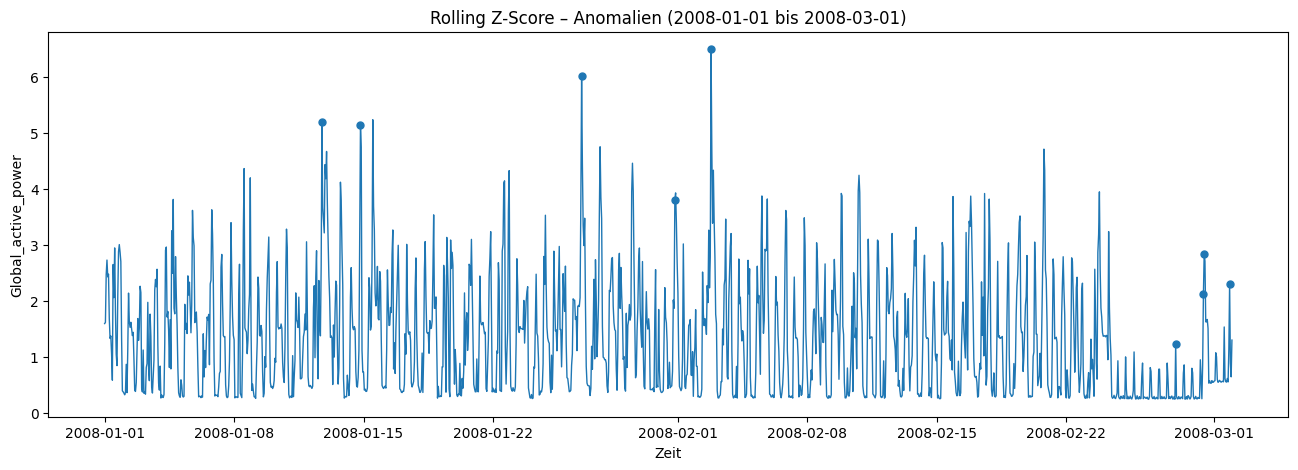

In [178]:
start, end = "2008-01-01", "2008-03-01"
tmp = df_h.loc[start:end]

plt.figure(figsize=(16,5))
plt.plot(tmp.index, tmp["Global_active_power"], linewidth=1)

anom_z = tmp[tmp["anomaly_z"] == 1]
plt.scatter(anom_z.index, anom_z["Global_active_power"], s=25)

plt.title(f"Rolling Z-Score – Anomalien ({start} bis {end})")
plt.xlabel("Zeit")
plt.ylabel("Global_active_power")
plt.show()


In [179]:
df_h["anomaly_combined"] = df_h["anomaly_any"]


In [180]:
out_path = r"C:\Users\NataliaArchipenko\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\Desktop\Projekt\Data\bearbeitet\household_power_with_anomalies_hourly.csv"
df_h.to_csv(out_path, index=True)
print("Gespeichert (inkl. Z-Score):", out_path)


Gespeichert (inkl. Z-Score): C:\Users\NataliaArchipenko\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\Desktop\Projekt\Data\bearbeitet\household_power_with_anomalies_hourly.csv
